# Flight Separator — Model Training

Trains a classifier to label each telemetry row as `taxing`, `landing-takeoff`, or `flight`.

**Features used:** `altitude`, `ground_speed`, `heading`

**Config:** Place your `config.yml` next to this notebook (or at the project root) with the shape:
```yaml
database:
  username: your-db-user
  password: your-db-password
  ip_address: your-db-host
  port: '50000'
  db_name: YOUR_DB_NAME
```

In [1]:
import sys
sys.path.insert(0, '..')  # so we can import from the project root

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from db_connection_params_handler import ConnectionParamsHandler
from db_factory import make_db_manager
from db_handlers.ibm_db2.airplane_info_db_access import AirplaneInfoDBAccess
from db_handlers.ibm_db2.MQTT_db_access import TelemetryMQTTDatabaseAccess
from mappers.telemetry_mapper import FormattedTelemetryMapper
from logic.position_assigner_instance import position_assigner

/opt/anaconda3/envs/intuosdash/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/intuosdash/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/intuosdash/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from ve

## 1. Connect to the database

In [ ]:
# CONFIG_PATH = 'config.yml'
CONFIG_PATH =  '/Users/adebanjiadelowo/Documents/GitHub/intuos-fdm-dashboard/config_notebook.yml'

connection = ConnectionParamsHandler(connection_filename=CONFIG_PATH)
db_manager = make_db_manager(connection)
telemetry_access = TelemetryMQTTDatabaseAccess(manager=db_manager)
print('Connected.')

Connected.


In [3]:
print(connection.db_name)
print(connection.ip_address, connection.port)


DB_SUN01
REDACTED_DB2_HOST 27010


In [4]:
airplane_access = AirplaneInfoDBAccess(db_manager)
airplane_info = airplane_access.get_all_airplane_info()

In [5]:
airplane_info

,marche,country,tc_holder,typedesignator,icao_id,numserie,annocostr,annoimma,ulmsn,experimentalsn,...,solo_01,use_camo_01,manual_input_01,glidersn,towingsn,engine_desc,hp,vfrn_01,ifu_present_01,fr_enable_01
0,D-0206,DE,193,K7,0,AB/7281,1961,2022,N,N,...,1,0,1,S,S,,,0,0,0
1,D-ENDK,DE,AVI346,DR40,37814,1318,1978,2021,N,N,...,1,0,1,N,N,,,0,1,1
2,D-KCIK,DE,SPO394,RF5,38772,51003,1971,2015,N,N,...,1,0,1,S,N,,,0,0,0
3,I-AMAT,IT,6,C152,31641,152-80995,1978,1986,N,N,...,0,0,0,N,N,None,None,0,0,0
4,I-CCBI,IT,4,M7,36013,10075C,1989,1989,N,N,...,1,0,1,N,N,,,0,1,0
5,I-CGTB,IT,34,201B,0,201B062,1988,2021,N,N,...,1,0,1,S,S,None,None,0,0,0
6,I-GDEL,IT,6001,P2006,0,,0,0,N,N,...,0,0,0,N,N,None,None,0,0,0
7,I-LZZY,IT,230,P28U,29880,28R-8031001,1981,2017,N,N,...,1,0,1,N,N,,,0,1,1
8,I-SRAA,IT,AVI346,DR40,37832,2789,2025,2025,N,N,...,1,0,1,N,N,DIESEL,0,1,0,0
9,I-SRAV,IT,6,C152,31641,152-84056,1979,2011,N,N,...,1,0,1,N,N,,,0,1,1


In [6]:
# (stale cell — data fetching is done in the cell below)

In [7]:
airplane_info

,marche,country,tc_holder,typedesignator,icao_id,numserie,annocostr,annoimma,ulmsn,experimentalsn,...,solo_01,use_camo_01,manual_input_01,glidersn,towingsn,engine_desc,hp,vfrn_01,ifu_present_01,fr_enable_01
0,D-0206,DE,193,K7,0,AB/7281,1961,2022,N,N,...,1,0,1,S,S,,,0,0,0
1,D-ENDK,DE,AVI346,DR40,37814,1318,1978,2021,N,N,...,1,0,1,N,N,,,0,1,1
2,D-KCIK,DE,SPO394,RF5,38772,51003,1971,2015,N,N,...,1,0,1,S,N,,,0,0,0
3,I-AMAT,IT,6,C152,31641,152-80995,1978,1986,N,N,...,0,0,0,N,N,None,None,0,0,0
4,I-CCBI,IT,4,M7,36013,10075C,1989,1989,N,N,...,1,0,1,N,N,,,0,1,0
5,I-CGTB,IT,34,201B,0,201B062,1988,2021,N,N,...,1,0,1,S,S,None,None,0,0,0
6,I-GDEL,IT,6001,P2006,0,,0,0,N,N,...,0,0,0,N,N,None,None,0,0,0
7,I-LZZY,IT,230,P28U,29880,28R-8031001,1981,2017,N,N,...,1,0,1,N,N,,,0,1,1
8,I-SRAA,IT,AVI346,DR40,37832,2789,2025,2025,N,N,...,1,0,1,N,N,DIESEL,0,1,0,0
9,I-SRAV,IT,6,C152,31641,152-84056,1979,2011,N,N,...,1,0,1,N,N,,,0,1,1


## 2. Pull labelled telemetry

We use the existing `PositionAssigner` + `FormattedTelemetryMapper` pipeline
to get processed rows with the current `attitude` label already applied.
Edit the list below to cover the registrations and date ranges you want.

In [8]:
# frames = []
# failed = []
# for marca in airplane_info['marche']:
#     print(f'Fetching {marca}')
#     try:
#         raw = telemetry_access.get_telemetry_by_marca(marca=marca)
#     except Exception as e:
#         print(f'  skipped — {type(e).__name__}: {e}')
#         failed.append(marca)
#         continue
#     if raw.dropna(how='all').empty:
#         print('  no data')
#         continue
#     mapper = FormattedTelemetryMapper(df_chunk_generator=raw, position_assigner=position_assigner)
#     df = mapper.new_generate_telemetry_samples()
#     if df.empty:
#         print('  no rows after mapping')
#         continue
#     frames.append(df)
#     print(f'  {len(df):,} rows')

# if failed:
#     print(f'\nSkipped (DB error): {failed}')
# if not frames:
#     raise RuntimeError("No data collected — check QUERIES or DB connection")

# data = pd.concat(frames, ignore_index=True)
# print(f'\nTotal rows: {len(data):,}')
# data.head()

In [9]:
QUERIES = [
    # (registration, start_date, end_date)
    ('I-SRAV', '2025-01-01', '2025-06-30'),
    ('I-CCBI', '2025-01-01', '2025-06-30'),
    ('D-ENDK', '2025-01-01', '2025-06-30')
    # add more as needed
]

frames = []
for marca, start, end in QUERIES:
    print(f'Fetching {marca}  {start} → {end} ...')
    raw = telemetry_access.get_telemetry_by_marca_datetime_interval(
        marca=marca, start_datetime=start, end_datetime=end
    )
    if raw.dropna(how='all').empty:
        print('  no data')
        continue
    mapper = FormattedTelemetryMapper(df_chunk_generator=raw, position_assigner=position_assigner)
    df = mapper.new_generate_telemetry_samples()
    frames.append(df)
    print(f'  {len(df):,} rows')

data = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows: {len(data):,}')
data.head()

Fetching I-SRAV  2025-01-01 → 2025-06-30 ...
  278,571 rows
Fetching I-CCBI  2025-01-01 → 2025-06-30 ...
  no data
Fetching D-ENDK  2025-01-01 → 2025-06-30 ...
  no data

Total rows: 278,571


,magnetic_heading,acc_x,acc_y,acc_z,pitch,roll,turn_rate,latitude,longitude,altitude,...,heading,vertical_speed,elevation,registration_id,id,date_time,label,attitude,unix_timestamp,height
0,NaN,0.09,-0.18,0.92,-1.0,-0.0,-0.0,42.383472,13.309072,2234.0,...,177.8,-0.16,2234.0,I-SRAV,1736953413,2025-01-15 15:03:33.600,9,stable_straight,1736953413,0.0
1,NaN,0.19,0.09,1.25,-1.0,-0.0,-0.0,42.383228,13.309079,2232.0,...,178.9,-0.21,2218.0,I-SRAV,1736953415,2025-01-15 15:03:35.500,2,ascending_straight,1736953415,14.0
2,NaN,0.21,0.04,0.99,-3.0,-0.0,-0.0,42.382717,13.309091,2231.0,...,179.4,-0.33,2218.0,I-SRAV,1736953416,2025-01-15 15:03:36.500,9,stable_straight,1736953416,13.0
3,NaN,0.21,0.09,0.99,-4.0,0.0,-0.0,42.382175,13.309118,2231.0,...,178.0,-0.58,2218.0,I-SRAV,1736953418,2025-01-15 15:03:38.600,9,stable_straight,1736953418,13.0
4,NaN,0.19,0.05,1.12,-5.0,-0.0,0.0,42.381886,13.309134,2231.0,...,178.6,-0.58,2218.0,I-SRAV,1736953419,2025-01-15 15:03:39.500,9,stable_straight,1736953419,13.0


In [17]:
data.to_csv('flight_separator_training_data.csv', index=False)

## 3. Clip features & prepare labels

The existing model clips these values — we apply the same bounds so the
training distribution matches what the model sees at inference time.

In [10]:
FEATURES = ['altitude', 'ground_speed', 'heading']

# Same clipping as FlightSeparator.__extract_labeled_samples
data['altitude']     = data['altitude'].clip(-1, 30_000)
data['ground_speed'] = data['ground_speed'].clip(-1, 500)

# The attitude column from PositionAssigner is the fine-grained label.
# Map it to the coarse flight-separator classes.
PHASE_MAP = {
    'taxing':           'taxing',
    'landing-takeoff':  'landing-takeoff',
    'ascending_straight': 'flight',
    'ascending_left':   'flight',
    'ascending_right':  'flight',
    'stable_straight':  'flight',
    'stable_left':      'flight',
    'stable_right':     'flight',
    'descending_straight': 'flight',
    'descending_left':  'flight',
    'descending_right': 'flight',
}
data['phase'] = data['attitude'].map(PHASE_MAP)
data = data.dropna(subset=FEATURES + ['phase'])

print(data['phase'].value_counts())
data[FEATURES + ['phase']].head()

phase
flight             272619
landing-takeoff      3571
taxing               2381
Name: count, dtype: int64


,altitude,ground_speed,heading,phase
0,2234.0,51.5,177.8,flight
1,2232.0,53.7,178.9,flight
2,2231.0,57.6,179.4,flight
3,2231.0,60.8,178.0,flight
4,2231.0,62.3,178.6,flight


## 4. Train / test split

In [11]:
X = data[FEATURES].values
y = data['phase'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')

Train: 222,856   Test: 55,715


## 5. Train model

Random Forest is the same family as the existing `.pkl`. Swap in any
sklearn-compatible classifier — the save/load mechanism is identical.

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
model.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 6. Evaluate

In [13]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f'5-fold CV F1 (weighted): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

                 precision    recall  f1-score   support

         flight       1.00      1.00      1.00     54525
landing-takeoff       0.96      0.95      0.96       714
         taxing       0.98      0.98      0.98       476

       accuracy                           1.00     55715
      macro avg       0.98      0.98      0.98     55715
   weighted avg       1.00      1.00      1.00     55715

5-fold CV F1 (weighted): 0.999 ± 0.000


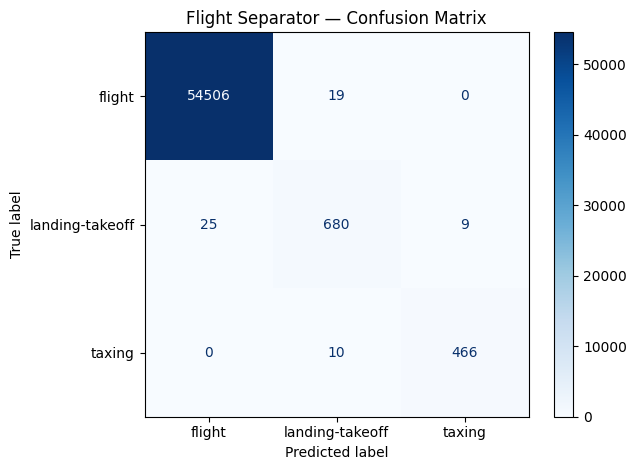

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Flight Separator — Confusion Matrix')
plt.tight_layout()
plt.show()

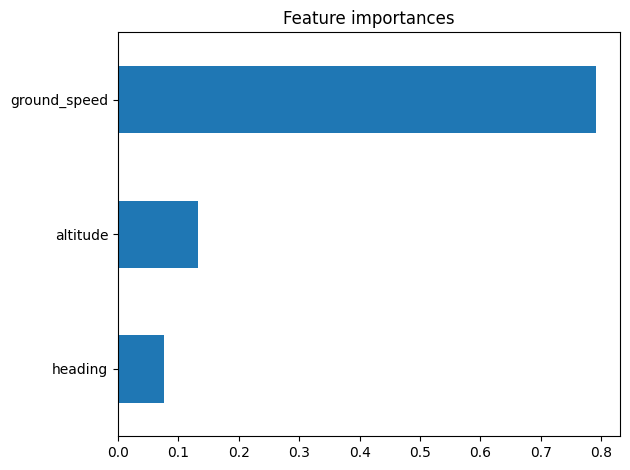

In [15]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importances.plot.barh()
plt.title('Feature importances')
plt.tight_layout()
plt.show()

## 7. Save artefacts

Drop the output files into `converters/flight_separator_data/` to replace the
existing model. The filename convention mirrors the existing `accuracy.pkl` variant.

In [16]:
OUT_DIR = Path('../converters/flight_separator_data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'retrained'  # change to 'accuracy', 'memory', or 'computation_time' to replace existing

# Model
joblib.dump(model, OUT_DIR / f'{MODEL_NAME}.pkl')

# Class names  — list ordered by model.classes_ index
class_names = list(model.classes_)
with open(OUT_DIR / f'{MODEL_NAME}_class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

# Feature list
with open(OUT_DIR / f'{MODEL_NAME}_selected_features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

print('Saved:')
for p in OUT_DIR.glob(f'{MODEL_NAME}*'):
    print(' ', p)

Saved:
  ../converters/flight_separator_data/retrained_class_names.json
  ../converters/flight_separator_data/retrained_selected_features.json
  ../converters/flight_separator_data/retrained.pkl
